
# 🍅 Tomato Disease State + 24h Progression
This notebook is designed for **Google Colab** and trains two kinds of models on the uploaded synthetic hourly tomato disease dataset:

1. **Baseline tabular models**
   - current disease presence (multi-label classification)
   - future 24h infection severity (multi-output regression)
   - trend after 24h is **derived** from current vs predicted future severity

2. **Sequence deep-learning models**
   - **LSTM**
   - **GRU**

The notebook is stage-aware and uses **past 24 hours** of greenhouse + crop-stage + disease-history signals.

## Outputs of the pipeline
For each of the 5 diseases:
- current disease probability / presence
- current severity %
- predicted severity after 24h
- 24h trend label: `absent`, `emerging`, `reducing`, `stable`, `worsening`

## Diseases
- early_blight
- late_blight
- leaf_mold
- powdery_mildew
- spider_mites


## SECTION 0 - Run ID & Path Setup

Initializes run tracking, detects project paths, and defines artifacts/checkpoint/log destinations for reproducible training runs.

In [415]:
# ─────────────────────────────────────────────────────────────
# SECTION 0: Run ID & Centralized Path Setup
# ─────────────────────────────────────────────────────────────

import os
import re
import logging
from datetime import datetime
from pathlib import Path

def find_project_root(start_path=None):
    """Find project root by looking for common marker files."""
    if start_path is None:
        start_path = os.path.abspath(".")
    current = Path(start_path)
    markers = ["pyproject.toml", "setup.py", ".git", "requirements.txt"]

    for _ in range(10):
        if any((current / m).exists() for m in markers):
            return str(current)
        parent = current.parent
        if parent == current:
            break
        current = parent
    return str(Path.cwd())

def is_valid_run_id(run_id_candidate):
    """Validate RUN_ID as YYYYMMDD_HHMMSS."""
    if not isinstance(run_id_candidate, str):
        return False
    return bool(re.match(r"^\d{8}_\d{6}$", run_id_candidate.strip()))

PROJECT_ROOT = find_project_root()
print(f"Project root    : {PROJECT_ROOT}")

RUN_ID = None
if ("RUN_ID" in globals() and RUN_ID is not None and
    isinstance(RUN_ID, str) and is_valid_run_id(RUN_ID)):
    print(f"Reusing RUN_ID from memory: {RUN_ID}")
else:
    MODEL_DIR = os.path.join(PROJECT_ROOT, "src", "agritwin_gh", "models")
    artifacts_base = os.path.join(MODEL_DIR, "artifacts")
    valid_run_ids = []

    if os.path.exists(artifacts_base):
        existing_runs = sorted([
            d for d in os.listdir(artifacts_base)
            if d.startswith("disease_progression_") and os.path.isdir(os.path.join(artifacts_base, d))
        ], reverse=True)

        for folder in existing_runs:
            candidate = folder.replace("disease_progression_", "")
            if is_valid_run_id(candidate):
                valid_run_ids.append(candidate)

    if valid_run_ids:
        RUN_ID = valid_run_ids[0]
        print(f"Detected & reusing existing RUN_ID: {RUN_ID}")
    else:
        RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
        print(f"Created new RUN_ID: {RUN_ID}")

print(f"Using Run ID     : {RUN_ID}")

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data", "processed", "Disease Progression",
    "tomato_disease_progression_synthetic_hourly.csv",
)
COLAB_DATA_FALLBACK = "/content/tomato_disease_progression_synthetic_hourly.csv"

MODEL_DIR = os.path.join(PROJECT_ROOT, "src", "agritwin_gh", "models")
MODEL_PATH = os.path.join(MODEL_DIR, f"disease_progression_{RUN_ID}.keras")

ARTIFACTS_DIR = os.path.join(MODEL_DIR, "artifacts", f"disease_progression_{RUN_ID}")
PLOTS_DIR = ARTIFACTS_DIR
METRICS_DIR = ARTIFACTS_DIR
LOGS_DIR = ARTIFACTS_DIR
REPORTS_DIR = ARTIFACTS_DIR

LSTM_CKPT_PATH = os.path.join(ARTIFACTS_DIR, f"best_lstm_{RUN_ID}.keras")
GRU_CKPT_PATH = os.path.join(ARTIFACTS_DIR, f"best_gru_{RUN_ID}.keras")

for d in [MODEL_DIR, ARTIFACTS_DIR, PLOTS_DIR, METRICS_DIR, LOGS_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

LOG_FILE = os.path.join(LOGS_DIR, f"run_{RUN_ID}.log")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE, encoding="utf-8"),
        logging.StreamHandler(),
    ],
)
logger = logging.getLogger("disease_progression")
logger.info(f"Run started | run_id={RUN_ID}")

def save_fig(fig, name: str, subdir: str = "") -> str:
    """Save figure to artifacts plot directory and return path."""
    target_dir = os.path.join(PLOTS_DIR, subdir) if subdir else PLOTS_DIR
    os.makedirs(target_dir, exist_ok=True)
    path = os.path.join(target_dir, f"{name}.png")
    fig.savefig(path, bbox_inches="tight", dpi=150)
    return path

resolved_csv_path = DATA_PATH if os.path.exists(DATA_PATH) else COLAB_DATA_FALLBACK
CONFIG = {
    "csv_path": resolved_csv_path,
    "history_window": 24,
    "forecast_horizon": 24,
    "severity_delta": 3.0,
    "severity_floor": 0.5,
    "presence_threshold": 0.5,
    "batch_size": 128,
    "epochs": 50,
    "learning_rate": 1e-3,
    "run_id": RUN_ID,
    "project_root": PROJECT_ROOT,
    "artifacts_dir": ARTIFACTS_DIR,
}

if not os.path.exists(CONFIG["csv_path"]):
    print(f"Dataset not found at: {CONFIG['csv_path']}")
    print("Set DATA_PATH/COLAB_DATA_FALLBACK or upload the CSV to /content.")
else:
    print("Found dataset:", CONFIG["csv_path"])

print(f"Dataset         : {CONFIG['csv_path']}")
print(f"Model save path : {MODEL_PATH}")
print(f"Artifacts dir   : {ARTIFACTS_DIR}")
print(f"Log file        : {LOG_FILE}")
logger.info(f"Paths configured | dataset={CONFIG['csv_path']} | artifacts={ARTIFACTS_DIR}")

2026-03-25 21:43:42,457 | INFO | Run started | run_id=20260325_145100
2026-03-25 21:43:42,461 | INFO | Paths configured | dataset=e:\AgriTwin-GH\data\processed\Disease Progression\tomato_disease_progression_synthetic_hourly.csv | artifacts=e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100


Project root    : e:\AgriTwin-GH
Detected & reusing existing RUN_ID: 20260325_145100
Using Run ID     : 20260325_145100
Found dataset: e:\AgriTwin-GH\data\processed\Disease Progression\tomato_disease_progression_synthetic_hourly.csv
Dataset         : e:\AgriTwin-GH\data\processed\Disease Progression\tomato_disease_progression_synthetic_hourly.csv
Model save path : e:\AgriTwin-GH\src\agritwin_gh\models\disease_progression_20260325_145100.keras
Artifacts dir   : e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100
Log file        : e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\run_20260325_145100.log


## SECTION 1 - Imports, ML Metrics & Global Setup

Loads core libraries, configures random seeds/theme, and prepares reusable metrics for training and evaluation.

In [416]:
import os
import re
import json
import math
import random
import logging
import warnings
from datetime import datetime
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier, MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc,
    explained_variance_score,
    median_absolute_error,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", palette="muted")

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## SECTION 2 - Load Hourly Dataset

Reads the configured disease progression CSV, parses timestamps, and prints a first structural overview of the data.

In [417]:

df = pd.read_csv(CONFIG["csv_path"])
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["timestamp", "disease_name"]).reset_index(drop=True)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Shape: (54240, 39)


,timestamp,cycle_id,cycle_label,season_label,stage_name,stage_index,days_from_cycle_start,day_of_year,week_of_year,hour,...,disease_cycle_id,disease_cycle_stage,outbreak_trigger_flag,control_action_flag,control_action_type,stage_susceptibility_score,disease_risk_score,hours_since_disease_onset,current_infection_pct,infection_growth_rate_hourly
0,2024-07-01,1,kharif_2024,southwest_monsoon,seedling,0,0.0,183,27,0,...,0,none,0,0,none,0.35,0.3500,NaN,0.0,0.0
1,2024-07-01,1,kharif_2024,southwest_monsoon,seedling,0,0.0,183,27,0,...,0,none,0,0,none,0.45,0.1007,NaN,0.0,0.0
2,2024-07-01,1,kharif_2024,southwest_monsoon,seedling,0,0.0,183,27,0,...,0,none,0,0,none,0.30,0.0817,NaN,0.0,0.0
3,2024-07-01,1,kharif_2024,southwest_monsoon,seedling,0,0.0,183,27,0,...,0,none,0,0,none,0.50,0.4125,NaN,0.0,0.0
4,2024-07-01,1,kharif_2024,southwest_monsoon,seedling,0,0.0,183,27,0,...,0,none,0,0,none,0.40,0.1893,NaN,0.0,0.0



Columns:
['timestamp', 'cycle_id', 'cycle_label', 'season_label', 'stage_name', 'stage_index', 'days_from_cycle_start', 'day_of_year', 'week_of_year', 'hour', 'hours_in_current_stage', 'stage_progress_pct', 'total_cycle_progress_pct', 'is_stage_transition', 'indoor_temp', 'indoor_humidity', 'indoor_air_velocity', 'indoor_CO2', 'solarradiation', 'day_night_flag', 'vpd', 'dew_point', 'leaf_wetness_proxy', 'temperature_rolling_mean_24h', 'humidity_rolling_mean_24h', 'vpd_proxy', 'cumulative_gdd_like_index', 'disease_name', 'disease_present_flag', 'disease_cycle_id', 'disease_cycle_stage', 'outbreak_trigger_flag', 'control_action_flag', 'control_action_type', 'stage_susceptibility_score', 'disease_risk_score', 'hours_since_disease_onset', 'current_infection_pct', 'infection_growth_rate_hourly']


## SECTION 3 - Data Sanity Checks

Verifies disease labels, crop stages, time range, and timestamp-row consistency before feature processing.

In [418]:

print("Unique diseases:", sorted(df["disease_name"].unique().tolist()))
print("Unique stages:", df["stage_name"].unique().tolist())
print("Time range:", df["timestamp"].min(), "to", df["timestamp"].max())
print("Rows per timestamp (should usually be 5):")
display(df.groupby("timestamp").size().value_counts().sort_index())


Unique diseases: ['early_blight', 'late_blight', 'leaf_mold', 'powdery_mildew', 'spider_mites']
Unique stages: ['seedling', 'early_vegetative', 'flowering_initiation', 'flowering', 'unripe', 'ripe']
Time range: 2024-07-01 00:00:00 to 2025-10-21 23:00:00
Rows per timestamp (should usually be 5):


5    10848
Name: count, dtype: int64

## SECTION 4 - Long-to-Wide Transformation

Converts disease-wise long records into one timestamp-level row with disease-specific feature columns.

In [419]:

SHARED_COLS = [
    "timestamp",
    "cycle_id", "cycle_label", "season_label",
    "stage_name", "stage_index", "days_from_cycle_start", "day_of_year",
    "week_of_year", "hour", "hours_in_current_stage", "stage_progress_pct",
    "total_cycle_progress_pct", "is_stage_transition",
    "indoor_temp", "indoor_humidity", "indoor_air_velocity", "indoor_CO2",
    "solarradiation", "day_night_flag", "vpd", "dew_point", "leaf_wetness_proxy",
    "temperature_rolling_mean_24h", "humidity_rolling_mean_24h", "vpd_proxy",
    "cumulative_gdd_like_index",
]

wide = df[SHARED_COLS].drop_duplicates("timestamp").sort_values("timestamp").reset_index(drop=True)

VALUE_COLS = [
    "disease_present_flag",
    "current_infection_pct",
    "infection_growth_rate_hourly",
    "stage_susceptibility_score",
    "disease_risk_score",
    "control_action_flag",
    "outbreak_trigger_flag",
]

for col in VALUE_COLS:
    piv = df.pivot(index="timestamp", columns="disease_name", values=col)
    piv.columns = [f"{col}__{c}" for c in piv.columns]
    piv = piv.reset_index()
    wide = wide.merge(piv, on="timestamp", how="left")

# add control action type as one-hot-ish simple indicators
action_piv = df.pivot(index="timestamp", columns="disease_name", values="control_action_type")
action_piv.columns = [f"control_action_type__{c}" for c in action_piv.columns]
action_piv = action_piv.reset_index()
wide = wide.merge(action_piv, on="timestamp", how="left")

# sort and fill
wide = wide.sort_values("timestamp").reset_index(drop=True)
wide = wide.fillna({
    c: 0 for c in wide.columns if c.startswith(("disease_present_flag__", "current_infection_pct__", "infection_growth_rate_hourly__", "stage_susceptibility_score__", "disease_risk_score__", "control_action_flag__", "outbreak_trigger_flag__"))
})
for c in [c for c in wide.columns if c.startswith("control_action_type__")]:
    wide[c] = wide[c].fillna("none")

DISEASES = sorted(df["disease_name"].unique().tolist())
PRES_COLS = [f"disease_present_flag__{d}" for d in DISEASES]
SEV_COLS = [f"current_infection_pct__{d}" for d in DISEASES]

print("Wide shape:", wide.shape)
display(wide.head())


Wide shape: (10848, 67)


,timestamp,cycle_id,cycle_label,season_label,stage_name,stage_index,days_from_cycle_start,day_of_year,week_of_year,hour,...,outbreak_trigger_flag__early_blight,outbreak_trigger_flag__late_blight,outbreak_trigger_flag__leaf_mold,outbreak_trigger_flag__powdery_mildew,outbreak_trigger_flag__spider_mites,control_action_type__early_blight,control_action_type__late_blight,control_action_type__leaf_mold,control_action_type__powdery_mildew,control_action_type__spider_mites
0,2024-07-01 00:00:00,1,kharif_2024,southwest_monsoon,seedling,0,0.0000,183,27,0,...,0,0,0,0,0,none,none,none,none,none
1,2024-07-01 01:00:00,1,kharif_2024,southwest_monsoon,seedling,0,0.0417,183,27,1,...,0,0,0,0,0,none,none,none,none,none
2,2024-07-01 02:00:00,1,kharif_2024,southwest_monsoon,seedling,0,0.0833,183,27,2,...,0,0,0,0,0,none,none,none,none,none
3,2024-07-01 03:00:00,1,kharif_2024,southwest_monsoon,seedling,0,0.1250,183,27,3,...,0,0,0,0,0,none,none,none,none,none
4,2024-07-01 04:00:00,1,kharif_2024,southwest_monsoon,seedling,0,0.1667,183,27,4,...,0,0,0,0,0,none,none,none,none,none


## SECTION 5 - Future Target Construction

Builds 24-hour future severity targets and derives categorical trend labels per disease.

In [420]:

H = CONFIG["forecast_horizon"]
DELTA = CONFIG["severity_delta"]
SEVERITY_FLOOR = CONFIG.get("severity_floor", 0.5)

for d in DISEASES:
    wide[f"future_severity_24h__{d}"] = wide[f"current_infection_pct__{d}"].shift(-H)

TREND_MAP = {0: "absent", 1: "emerging", 2: "reducing", 3: "stable", 4: "worsening"}

def compute_trend(curr, fut, delta=3.0, floor=0.5):
    if pd.isna(fut) or pd.isna(curr):
        return np.nan

    curr = float(curr)
    fut = float(fut)

    # Treat near-zero severity as zero so rounded 0.00 values are not tagged as emerging.
    curr_eff = 0.0 if curr <= floor else curr
    fut_eff = 0.0 if fut <= floor else fut

    if curr_eff <= 0 and fut_eff <= 0:
        return 0
    if curr_eff <= 0 and fut_eff > 0:
        return 1

    diff = fut_eff - curr_eff
    if diff < -delta:
        return 2
    if diff > delta:
        return 4
    return 3

for d in DISEASES:
    wide[f"trend_24h__{d}"] = [
        compute_trend(c, f, DELTA, SEVERITY_FLOOR)
        for c, f in zip(wide[f"current_infection_pct__{d}"], wide[f"future_severity_24h__{d}"])
    ]

# remove rows without future targets
target_cols = [f"future_severity_24h__{d}" for d in DISEASES] + [f"trend_24h__{d}" for d in DISEASES]
model_df = wide.dropna(subset=target_cols).reset_index(drop=True)

print("Model dataframe shape:", model_df.shape)
display(model_df[[ "timestamp"] + PRES_COLS + SEV_COLS + [f"future_severity_24h__{d}" for d in DISEASES] + [f"trend_24h__{d}" for d in DISEASES]].head())

Model dataframe shape: (10824, 77)


,timestamp,disease_present_flag__early_blight,disease_present_flag__late_blight,disease_present_flag__leaf_mold,disease_present_flag__powdery_mildew,disease_present_flag__spider_mites,current_infection_pct__early_blight,current_infection_pct__late_blight,current_infection_pct__leaf_mold,current_infection_pct__powdery_mildew,...,future_severity_24h__early_blight,future_severity_24h__late_blight,future_severity_24h__leaf_mold,future_severity_24h__powdery_mildew,future_severity_24h__spider_mites,trend_24h__early_blight,trend_24h__late_blight,trend_24h__leaf_mold,trend_24h__powdery_mildew,trend_24h__spider_mites
0,2024-07-01 00:00:00,0,0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-07-01 01:00:00,0,0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-07-01 02:00:00,0,0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-07-01 03:00:00,0,0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-07-01 04:00:00,0,0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## SECTION 6 - Feature Encoding Pipeline

Encodes categorical variables, prepares numeric feature sets, and defines target exclusions for modeling.

In [421]:
# --- FIXED FEATURE ENCODING CELL ---

# base categorical columns
BASE_CAT_COLS = ["cycle_label", "season_label", "stage_name"]

# dynamically include per-disease control_action_type columns
ACTION_TYPE_COLS = [c for c in model_df.columns if c.startswith("control_action_type__")]

CAT_COLS = BASE_CAT_COLS + ACTION_TYPE_COLS

NUM_BASE_COLS = [
    "cycle_id", "stage_index", "days_from_cycle_start", "day_of_year", "week_of_year",
    "hour", "hours_in_current_stage", "stage_progress_pct", "total_cycle_progress_pct",
    "is_stage_transition", "indoor_temp", "indoor_humidity", "indoor_air_velocity",
    "indoor_CO2", "solarradiation", "day_night_flag", "vpd", "dew_point",
    "leaf_wetness_proxy", "temperature_rolling_mean_24h", "humidity_rolling_mean_24h",
    "vpd_proxy", "cumulative_gdd_like_index",
]

DISEASE_SIGNAL_COLS = []
for d in DISEASES:
    DISEASE_SIGNAL_COLS.extend([
        f"disease_present_flag__{d}",
        f"current_infection_pct__{d}",
        f"infection_growth_rate_hourly__{d}",
        f"stage_susceptibility_score__{d}",
        f"disease_risk_score__{d}",
        f"control_action_flag__{d}",
        f"outbreak_trigger_flag__{d}",
    ])

# one-hot encode all categorical fields, including control_action_type__*
model_df_enc = pd.get_dummies(
    model_df,
    columns=CAT_COLS,
    drop_first=False,
    dtype=np.float32
)

TARGET_EXCLUDE = (
    ["timestamp"]
    + PRES_COLS
    + SEV_COLS
    + [f"future_severity_24h__{d}" for d in DISEASES]
    + [f"trend_24h__{d}" for d in DISEASES]
    + CAT_COLS
)

feature_cols = [c for c in model_df_enc.columns if c not in TARGET_EXCLUDE]

print("Categorical columns encoded:", CAT_COLS)
print("Number of encoded feature columns:", len(feature_cols))
print(feature_cols[:30])

Categorical columns encoded: ['cycle_label', 'season_label', 'stage_name', 'control_action_type__early_blight', 'control_action_type__late_blight', 'control_action_type__leaf_mold', 'control_action_type__powdery_mildew', 'control_action_type__spider_mites']
Number of encoded feature columns: 82
['cycle_id', 'stage_index', 'days_from_cycle_start', 'day_of_year', 'week_of_year', 'hour', 'hours_in_current_stage', 'stage_progress_pct', 'total_cycle_progress_pct', 'is_stage_transition', 'indoor_temp', 'indoor_humidity', 'indoor_air_velocity', 'indoor_CO2', 'solarradiation', 'day_night_flag', 'vpd', 'dew_point', 'leaf_wetness_proxy', 'temperature_rolling_mean_24h', 'humidity_rolling_mean_24h', 'vpd_proxy', 'cumulative_gdd_like_index', 'infection_growth_rate_hourly__early_blight', 'infection_growth_rate_hourly__late_blight', 'infection_growth_rate_hourly__leaf_mold', 'infection_growth_rate_hourly__powdery_mildew', 'infection_growth_rate_hourly__spider_mites', 'stage_susceptibility_score__earl

## SECTION 7 - Encoded Feature Integrity Check

Validates that all selected model features are numeric and confirms there are no remaining object-type columns.

In [422]:
# sanity check
bad_cols = model_df_enc[feature_cols].select_dtypes(include=["object"]).columns.tolist()
print("Object columns still present:", bad_cols)
assert len(bad_cols) == 0, f"Still found object columns: {bad_cols}"

Object columns still present: []


## SECTION 8 - Time-Based Train/Val/Test Split

Creates chronological train, validation, and test partitions to prevent temporal leakage.

In [423]:

n = len(model_df_enc)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df_enc.iloc[:train_end].copy()
val_df   = model_df_enc.iloc[train_end:val_end].copy()
test_df  = model_df_enc.iloc[val_end:].copy()

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print("Train range:", train_df["timestamp"].min(), "to", train_df["timestamp"].max())
print("Val range  :", val_df["timestamp"].min(), "to", val_df["timestamp"].max())
print("Test range :", test_df["timestamp"].min(), "to", test_df["timestamp"].max())


Train: (7576, 103) Val: (1624, 103) Test: (1624, 103)
Train range: 2024-07-01 00:00:00 to 2025-06-06 15:00:00
Val range  : 2025-06-06 16:00:00 to 2025-08-14 07:00:00
Test range : 2025-08-14 08:00:00 to 2025-10-20 23:00:00


## SECTION 9 - Baseline Lag Feature Matrix

Creates flattened lag-window features and aligned baseline targets for presence, severity, and trend tasks.

In [424]:

WINDOW = CONFIG["history_window"]

# Use only feature columns for lag generation
base_mat = model_df_enc[["timestamp"] + feature_cols + PRES_COLS + SEV_COLS + [f"future_severity_24h__{d}" for d in DISEASES] + [f"trend_24h__{d}" for d in DISEASES]].copy()

lag_feature_cols = []
lagged = base_mat.copy()

for lag in range(1, WINDOW + 1):
    shifted = base_mat[feature_cols + SEV_COLS + PRES_COLS].shift(lag)
    shifted.columns = [f"{c}__lag{lag}" for c in shifted.columns]
    lagged = pd.concat([lagged, shifted], axis=1)
    lag_feature_cols.extend(shifted.columns.tolist())

lagged = lagged.dropna().reset_index(drop=True)

# preserve time-based split boundaries by timestamp
train_lag = lagged[lagged["timestamp"] <= train_df["timestamp"].max()].copy()
val_lag = lagged[(lagged["timestamp"] > train_df["timestamp"].max()) & (lagged["timestamp"] <= val_df["timestamp"].max())].copy()
test_lag = lagged[lagged["timestamp"] > val_df["timestamp"].max()].copy()

X_train_base = train_lag[feature_cols + lag_feature_cols]
X_val_base   = val_lag[feature_cols + lag_feature_cols]
X_test_base  = test_lag[feature_cols + lag_feature_cols]

y_train_presence = train_lag[PRES_COLS].astype(int)
y_val_presence   = val_lag[PRES_COLS].astype(int)
y_test_presence  = test_lag[PRES_COLS].astype(int)

future_sev_cols = [f"future_severity_24h__{d}" for d in DISEASES]
trend_cols = [f"trend_24h__{d}" for d in DISEASES]

y_train_future_sev = train_lag[future_sev_cols].astype(float)
y_val_future_sev   = val_lag[future_sev_cols].astype(float)
y_test_future_sev  = test_lag[future_sev_cols].astype(float)

y_train_trend = train_lag[trend_cols].astype(int)
y_val_trend   = val_lag[trend_cols].astype(int)
y_test_trend  = test_lag[trend_cols].astype(int)

print("Baseline X shapes:", X_train_base.shape, X_val_base.shape, X_test_base.shape)


Baseline X shapes: (7552, 2290) (1624, 2290) (1624, 2290)


## SECTION 10 - Baseline Presence Model Training

Fits the multi-output baseline classifier for current disease presence probabilities.

In [425]:

presence_baseline = MultiOutputClassifier(
    HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=200,
        random_state=SEED
    )
)
presence_baseline.fit(X_train_base, y_train_presence)

val_presence_prob = np.column_stack([
    est.predict_proba(X_val_base)[:, 1] if est.predict_proba(X_val_base).shape[1] > 1 else np.zeros(len(X_val_base))
    for est in presence_baseline.estimators_
])
test_presence_prob = np.column_stack([
    est.predict_proba(X_test_base)[:, 1] if est.predict_proba(X_test_base).shape[1] > 1 else np.zeros(len(X_test_base))
    for est in presence_baseline.estimators_
])

val_presence_pred = (val_presence_prob >= CONFIG["presence_threshold"]).astype(int)
test_presence_pred = (test_presence_prob >= CONFIG["presence_threshold"]).astype(int)

print("Done.")


Done.


## SECTION 11 - Baseline Future Severity Model

Trains the multi-output baseline regressor to forecast severity values 24 hours ahead.

In [426]:

future_sev_baseline = MultiOutputRegressor(
    HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=6,
        max_iter=250,
        random_state=SEED
    )
)
future_sev_baseline.fit(X_train_base, y_train_future_sev)

val_future_sev_pred = future_sev_baseline.predict(X_val_base)
test_future_sev_pred = future_sev_baseline.predict(X_test_base)

# clip to valid severity range
val_future_sev_pred = np.clip(val_future_sev_pred, 0, 100)
test_future_sev_pred = np.clip(test_future_sev_pred, 0, 100)

print("Done.")


Done.


## SECTION 12 - Baseline Trend Derivation

Converts predicted future severity values into trend-class predictions using rule-based thresholds.

In [427]:

def derive_trend_matrix(curr_sev, fut_sev_pred, delta=3.0):
    out = np.zeros_like(curr_sev, dtype=int)
    for i in range(curr_sev.shape[0]):
        for j in range(curr_sev.shape[1]):
            c = float(curr_sev[i, j])
            f = float(fut_sev_pred[i, j])
            out[i, j] = compute_trend(c, f, delta)
    return out

val_curr_sev = val_lag[SEV_COLS].values
test_curr_sev = test_lag[SEV_COLS].values

val_trend_pred = derive_trend_matrix(val_curr_sev, val_future_sev_pred, CONFIG["severity_delta"])
test_trend_pred = derive_trend_matrix(test_curr_sev, test_future_sev_pred, CONFIG["severity_delta"])


## SECTION 13 - Evaluation Utilities

Defines reusable reporting helpers for classification, regression, and multi-class trend analysis.

In [428]:

def multilabel_presence_report(y_true_df, y_pred_arr, diseases, title="Presence"):
    y_true = y_true_df.values
    print(f"\n===== {title} =====")
    print("Micro F1 :", round(f1_score(y_true, y_pred_arr, average="micro", zero_division=0), 4))
    print("Macro F1 :", round(f1_score(y_true, y_pred_arr, average="macro", zero_division=0), 4))
    print("Weighted F1 :", round(f1_score(y_true, y_pred_arr, average="weighted", zero_division=0), 4))
    print("Micro Precision :", round(precision_score(y_true, y_pred_arr, average="micro", zero_division=0), 4))
    print("Micro Recall :", round(recall_score(y_true, y_pred_arr, average="micro", zero_division=0), 4))
    for i, d in enumerate(diseases):
        print(f"\n[{d}]")
        print(classification_report(y_true[:, i], y_pred_arr[:, i], zero_division=0))

def regression_report(y_true_df, y_pred_arr, diseases, title="Future Severity"):
    print(f"\n===== {title} =====")
    all_mae, all_rmse, all_r2 = [], [], []
    for i, d in enumerate(diseases):
        yt = y_true_df.iloc[:, i].values
        yp = y_pred_arr[:, i]
        mae = mean_absolute_error(yt, yp)
        rmse = math.sqrt(mean_squared_error(yt, yp))
        r2 = r2_score(yt, yp)
        all_mae.append(mae); all_rmse.append(rmse); all_r2.append(r2)
        print(f"{d:18s} | MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.4f}")
    print(f"Overall mean MAE : {np.mean(all_mae):.3f}")
    print(f"Overall mean RMSE: {np.mean(all_rmse):.3f}")
    print(f"Overall mean R2  : {np.mean(all_r2):.4f}")

from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score
import numpy as np
import pandas as pd

TREND_LABELS = ["absent", "emerging", "reducing", "stable", "worsening"]
TREND_TO_INT = {name: i for i, name in enumerate(TREND_LABELS)}
INT_TO_TREND = {i: name for name, i in TREND_TO_INT.items()}

def trend_report(y_true, y_pred, diseases, title="Trend Report"):
    print(f"\n===== {title} =====")

    # convert safely to numpy
    if isinstance(y_true, pd.DataFrame) or isinstance(y_true, pd.Series):
        y_true = y_true.to_numpy()
    else:
        y_true = np.asarray(y_true)

    if isinstance(y_pred, pd.DataFrame) or isinstance(y_pred, pd.Series):
        y_pred = y_pred.to_numpy()
    else:
        y_pred = np.asarray(y_pred)

    macro_f1s = []
    bal_accs = []
    full_labels = list(range(len(TREND_LABELS)))  # [0,1,2,3,4]

    for i, d in enumerate(diseases):
        yt = y_true[:, i].astype(int)
        yp = y_pred[:, i].astype(int)

        macro_f1 = f1_score(yt, yp, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(yt, yp)

        macro_f1s.append(macro_f1)
        bal_accs.append(bal_acc)

        print(f"\n[{d}] Macro-F1={macro_f1:.4f} | Balanced-Acc={bal_acc:.4f}")
        print(
            classification_report(
                yt,
                yp,
                labels=full_labels,
                target_names=TREND_LABELS,
                zero_division=0
            )
        )

    print("\nOverall Trend Macro-F1      :", round(float(np.mean(macro_f1s)), 4))
    print("Overall Trend Balanced-Acc :", round(float(np.mean(bal_accs)), 4))

## SECTION 14 - Baseline Validation Performance

Runs baseline validation metrics to inspect model quality before final test evaluation.

In [429]:

multilabel_presence_report(y_val_presence, val_presence_pred, DISEASES, title="Validation Presence - Baseline")
regression_report(y_val_future_sev, val_future_sev_pred, DISEASES, title="Validation Future Severity - Baseline")
trend_report(y_val_trend, val_trend_pred, DISEASES, title="Validation Trend - Baseline")



===== Validation Presence - Baseline =====
Micro F1 : 0.9985
Macro F1 : 0.9958
Weighted F1 : 0.9985
Micro Precision : 1.0
Micro Recall : 0.997

[early_blight]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1174
           1       1.00      1.00      1.00       450

    accuracy                           1.00      1624
   macro avg       1.00      1.00      1.00      1624
weighted avg       1.00      1.00      1.00      1624


[late_blight]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       524
           1       1.00      1.00      1.00      1100

    accuracy                           1.00      1624
   macro avg       1.00      1.00      1.00      1624
weighted avg       1.00      1.00      1.00      1624


[leaf_mold]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1591
           1       1.00      0.97      0.98      

## SECTION 15 - Baseline Test Performance

Runs baseline model evaluation on the held-out test split for presence, future severity, and trend quality.

In [430]:

multilabel_presence_report(y_test_presence, test_presence_pred, DISEASES, title="Test Presence - Baseline")
regression_report(y_test_future_sev, test_future_sev_pred, DISEASES, title="Test Future Severity - Baseline")
trend_report(y_test_trend, test_trend_pred, DISEASES, title="Test Trend - Baseline")



===== Test Presence - Baseline =====
Micro F1 : 0.9939
Macro F1 : 0.9923
Weighted F1 : 0.9938
Micro Precision : 0.9992
Micro Recall : 0.9888

[early_blight]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1040
           1       1.00      1.00      1.00       584

    accuracy                           1.00      1624
   macro avg       1.00      1.00      1.00      1624
weighted avg       1.00      1.00      1.00      1624


[late_blight]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1230
           1       0.99      1.00      1.00       394

    accuracy                           1.00      1624
   macro avg       1.00      1.00      1.00      1624
weighted avg       1.00      1.00      1.00      1624


[leaf_mold]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1141
           1       1.00      1.00      1.00       4

## SECTION 16 - Sequence Window Construction

Builds rolling sequence tensors and aligned targets for deep sequence model training and evaluation.

In [431]:

seq_source = model_df_enc.reset_index(drop=True).copy()

seq_feature_cols = feature_cols + SEV_COLS + PRES_COLS
seq_target_presence_cols = PRES_COLS
seq_target_future_cols = future_sev_cols

def build_sequences(frame, feature_cols, presence_cols, future_cols, window=24):
    X, y_presence, y_future, timestamps = [], [], [], []
    values = frame[feature_cols].values.astype(np.float32)
    y_pres = frame[presence_cols].values.astype(np.float32)
    y_fut = frame[future_cols].values.astype(np.float32)
    ts = frame["timestamp"].values
    for i in range(window - 1, len(frame)):
        X.append(values[i - window + 1:i + 1])
        y_presence.append(y_pres[i])
        y_future.append(y_fut[i])
        timestamps.append(ts[i])
    return np.array(X), np.array(y_presence), np.array(y_future), np.array(timestamps)

X_seq_all, y_seq_presence_all, y_seq_future_all, ts_seq_all = build_sequences(
    seq_source, seq_feature_cols, seq_target_presence_cols, seq_target_future_cols, window=WINDOW
)

# split by timestamp boundary
train_mask = ts_seq_all <= np.datetime64(train_df["timestamp"].max())
val_mask   = (ts_seq_all > np.datetime64(train_df["timestamp"].max())) & (ts_seq_all <= np.datetime64(val_df["timestamp"].max()))
test_mask  = ts_seq_all > np.datetime64(val_df["timestamp"].max())

X_train_seq = X_seq_all[train_mask]
X_val_seq   = X_seq_all[val_mask]
X_test_seq  = X_seq_all[test_mask]

y_train_seq_presence = y_seq_presence_all[train_mask]
y_val_seq_presence   = y_seq_presence_all[val_mask]
y_test_seq_presence  = y_seq_presence_all[test_mask]

y_train_seq_future = y_seq_future_all[train_mask] / 100.0
y_val_seq_future   = y_seq_future_all[val_mask] / 100.0
y_test_seq_future  = y_seq_future_all[test_mask] / 100.0

print("Sequence shapes:")
print("X_train_seq:", X_train_seq.shape)
print("X_val_seq  :", X_val_seq.shape)
print("X_test_seq :", X_test_seq.shape)


Sequence shapes:
X_train_seq: (7553, 24, 92)
X_val_seq  : (1624, 24, 92)
X_test_seq : (1624, 24, 92)


## SECTION 17 - Sequence Feature Scaling

Fits the sequence scaler on train features and transforms validation/test sequences consistently.

In [432]:

feature_scaler = StandardScaler()

n_train, win, n_feat = X_train_seq.shape
X_train_flat = X_train_seq.reshape(-1, n_feat)
X_val_flat   = X_val_seq.reshape(-1, n_feat)
X_test_flat  = X_test_seq.reshape(-1, n_feat)

feature_scaler.fit(X_train_flat)

X_train_seq_sc = feature_scaler.transform(X_train_flat).reshape(X_train_seq.shape)
X_val_seq_sc   = feature_scaler.transform(X_val_flat).reshape(X_val_seq.shape)
X_test_seq_sc  = feature_scaler.transform(X_test_flat).reshape(X_test_seq.shape)

print("Scaled sequence shapes:", X_train_seq_sc.shape, X_val_seq_sc.shape, X_test_seq_sc.shape)


Scaled sequence shapes: (7553, 24, 92) (1624, 24, 92) (1624, 24, 92)


## SECTION 18 - LSTM/GRU Model Builder

Defines the shared deep architecture factory with multi-head outputs for presence and future severity.

In [433]:

def build_sequence_model(cell_type="lstm", input_shape=None, n_diseases=5, learning_rate=1e-3):
    inp = keras.Input(shape=input_shape, name="sequence_input")

    if cell_type.lower() == "gru":
        x = layers.GRU(96, return_sequences=True)(inp)
        x = layers.Dropout(0.999)(x)
        x = layers.GRU(64)(x)
    else:
        x = layers.LSTM(96, return_sequences=True)(inp)
        x = layers.Dropout(0.92)(x)
        x = layers.LSTM(64)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.85)(x)

    presence_head = layers.Dense(n_diseases, activation="sigmoid", name="presence_head")(x)
    future_head = layers.Dense(n_diseases, activation="sigmoid", name="future_head")(x)

    model = keras.Model(inp, [presence_head, future_head], name=f"{cell_type.upper()}_disease_progression")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss={
            "presence_head": "binary_crossentropy",
            "future_head": "mse",
        },
        metrics={
            "presence_head": [keras.metrics.BinaryAccuracy(name="bin_acc")],
            "future_head": [keras.metrics.MeanAbsoluteError(name="mae")],
        },
    )
    return model


## SECTION 19 - Train LSTM with Checkpointing

Trains the LSTM model with early stopping, LR scheduling, and best-checkpoint saving.

In [434]:
dropoutcallbacks_lstm = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, verbose=1),
    keras.callbacks.ModelCheckpoint(
        filepath=LSTM_CKPT_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
        verbose=1,
    ),
]

lstm_model = build_sequence_model(
    cell_type="lstm",
    input_shape=(X_train_seq_sc.shape[1], X_train_seq_sc.shape[2]),
    n_diseases=len(DISEASES),
    learning_rate=CONFIG["learning_rate"],
)

history_lstm = lstm_model.fit(
    X_train_seq_sc,
    {"presence_head": y_train_seq_presence, "future_head": y_train_seq_future},
    validation_data=(X_val_seq_sc, {"presence_head": y_val_seq_presence, "future_head": y_val_seq_future}),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=callbacks_lstm,
    verbose=1,
)

best_lstm_val_loss = float(np.min(history_lstm.history["val_loss"]))
best_lstm_epoch = int(np.argmin(history_lstm.history["val_loss"]) + 1)
print(f"Best LSTM checkpoint at epoch {best_lstm_epoch} | val_loss={best_lstm_val_loss:.5f}")
logger.info(f"LSTM trained | best_val_loss={best_lstm_val_loss:.5f} | ckpt={LSTM_CKPT_PATH}")

Epoch 1/50
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - future_head_loss: 0.2027 - future_head_mae: 0.4201 - loss: 0.8684 - presence_head_bin_acc: 0.5867 - presence_head_loss: 0.6657
Epoch 1: val_loss did not improve from 0.26782
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - future_head_loss: 0.1757 - future_head_mae: 0.3832 - loss: 0.7913 - presence_head_bin_acc: 0.6434 - presence_head_loss: 0.6129 - val_future_head_loss: 0.0678 - val_future_head_mae: 0.2299 - val_loss: 0.6020 - val_presence_head_bin_acc: 0.7782 - val_presence_head_loss: 0.5313 - learning_rate: 0.0010
Epoch 2/50
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - future_head_loss: 0.1159 - future_head_mae: 0.2735 - loss: 0.5800 - presence_head_bin_acc: 0.7722 - presence_head_loss: 0.4641
Epoch 2: val_loss did not improve from 0.26782
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - future_head_loss: 0.1049 - future_head_mae: 0.2519 - loss: 0.5329 - presence_head_bin_acc: 0.7914 - presence_head_loss: 0.4222 - val_future_head_loss: 0.0158 -

2026-03-25 21:52:21,165 | INFO | LSTM trained | best_val_loss=0.26926 | ckpt=e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\best_lstm_20260325_145100.keras


Best LSTM checkpoint at epoch 9 | val_loss=0.26926


## SECTION 20 - Train GRU & Select Best Checkpoint

Trains the GRU model and then selects the global best checkpoint between LSTM and GRU.

In [435]:
callbacks_gru = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=16, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, verbose=1),
    keras.callbacks.ModelCheckpoint(
        filepath=GRU_CKPT_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
        verbose=1,
    ),
]

gru_model = build_sequence_model(
    cell_type="gru",
    input_shape=(X_train_seq_sc.shape[1], X_train_seq_sc.shape[2]),
    n_diseases=len(DISEASES),
    learning_rate=CONFIG["learning_rate"],
)

history_gru = gru_model.fit(
    X_train_seq_sc,
    {"presence_head": y_train_seq_presence, "future_head": y_train_seq_future},
    validation_data=(X_val_seq_sc, {"presence_head": y_val_seq_presence, "future_head": y_val_seq_future}),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=callbacks_gru,
    verbose=1,
)

best_gru_val_loss = float(np.min(history_gru.history["val_loss"]))
best_gru_epoch = int(np.argmin(history_gru.history["val_loss"]) + 1)
print(f"Best GRU checkpoint at epoch {best_gru_epoch} | val_loss={best_gru_val_loss:.5f}")
logger.info(f"GRU trained | best_val_loss={best_gru_val_loss:.5f} | ckpt={GRU_CKPT_PATH}")

if best_lstm_val_loss <= best_gru_val_loss:
    BEST_MODEL_NAME = "lstm"
    BEST_MODEL_CKPT_PATH = LSTM_CKPT_PATH
    BEST_VAL_LOSS = best_lstm_val_loss
else:
    BEST_MODEL_NAME = "gru"
    BEST_MODEL_CKPT_PATH = GRU_CKPT_PATH
    BEST_VAL_LOSS = best_gru_val_loss

print(f"Global best checkpoint: {BEST_MODEL_NAME.upper()} | val_loss={BEST_VAL_LOSS:.5f}")
logger.info(f"Global best model | name={BEST_MODEL_NAME} | val_loss={BEST_VAL_LOSS:.5f} | ckpt={BEST_MODEL_CKPT_PATH}")

Epoch 1/50
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - future_head_loss: 0.2041 - future_head_mae: 0.4249 - loss: 0.9200 - presence_head_bin_acc: 0.5594 - presence_head_loss: 0.7160
Epoch 1: val_loss improved from None to 0.80465, saving model to e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\best_gru_20260325_145100.keras

Epoch 1: finished saving model to e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\best_gru_20260325_145100.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - future_head_loss: 0.1858 - future_head_mae: 0.4031 - loss: 0.8962 - presence_head_bin_acc: 0.5711 - presence_head_loss: 0.7109 - val_future_head_loss: 0.0957 - val_future_head_mae: 0.2898 - val_loss: 0.8046 - val_presence_head_bin_acc: 0.6436 - val_presence_head_loss: 0.7092 - learning_rate: 0.0010
Epoch 2/50
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - future_head_loss: 0.1391 - future_head_mae: 0.3362 - loss: 0.8332 - presence_head_bin_acc: 0

2026-03-25 21:55:25,087 | INFO | GRU trained | best_val_loss=0.64335 | ckpt=e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\best_gru_20260325_145100.keras
2026-03-25 21:55:25,088 | INFO | Global best model | name=lstm | val_loss=0.26926 | ckpt=e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\best_lstm_20260325_145100.keras


Best GRU checkpoint at epoch 10 | val_loss=0.64335
Global best checkpoint: LSTM | val_loss=0.26926


## SECTION 21 - Training Curves

Plots and saves loss and key head metrics to visualize optimization behavior across epochs.

Saved training curves -> e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\lstm_training_curves.png


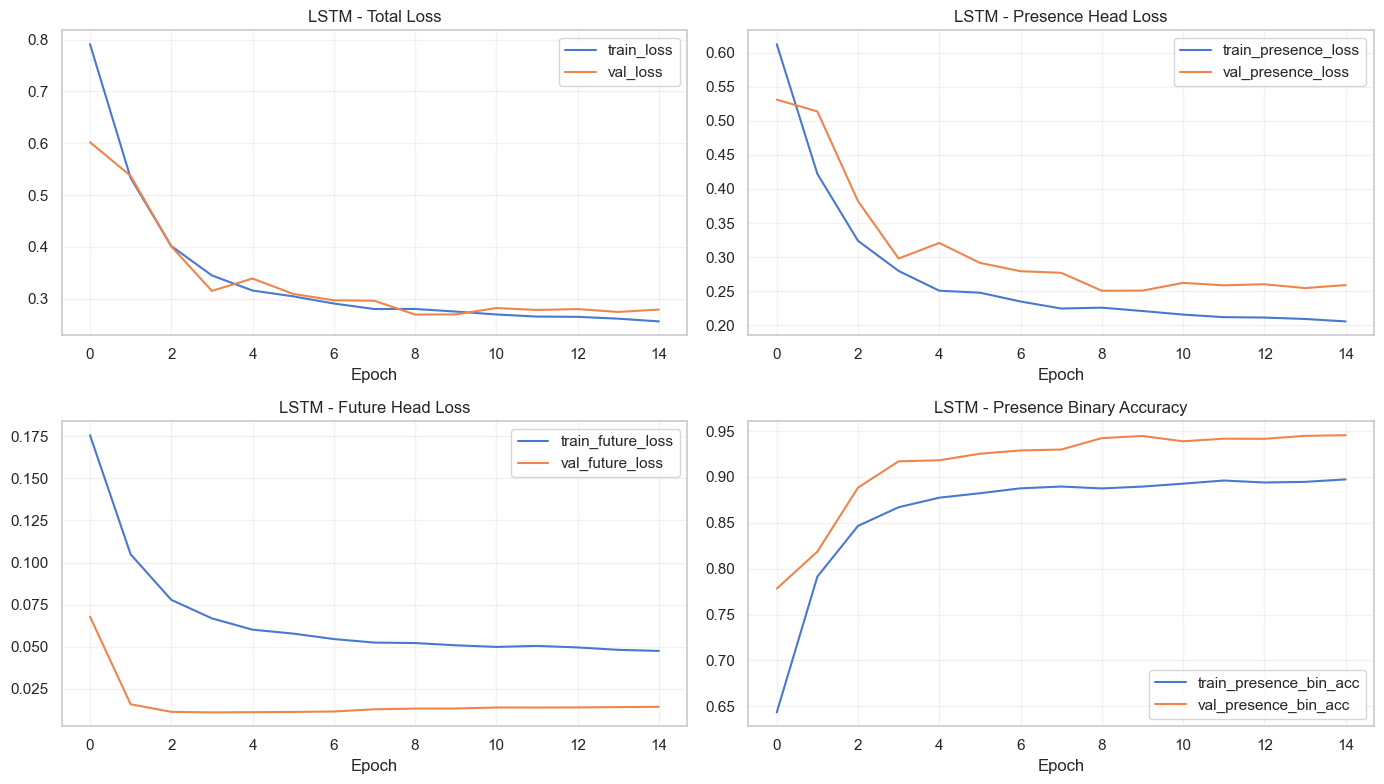

Saved training curves -> e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\gru_training_curves.png


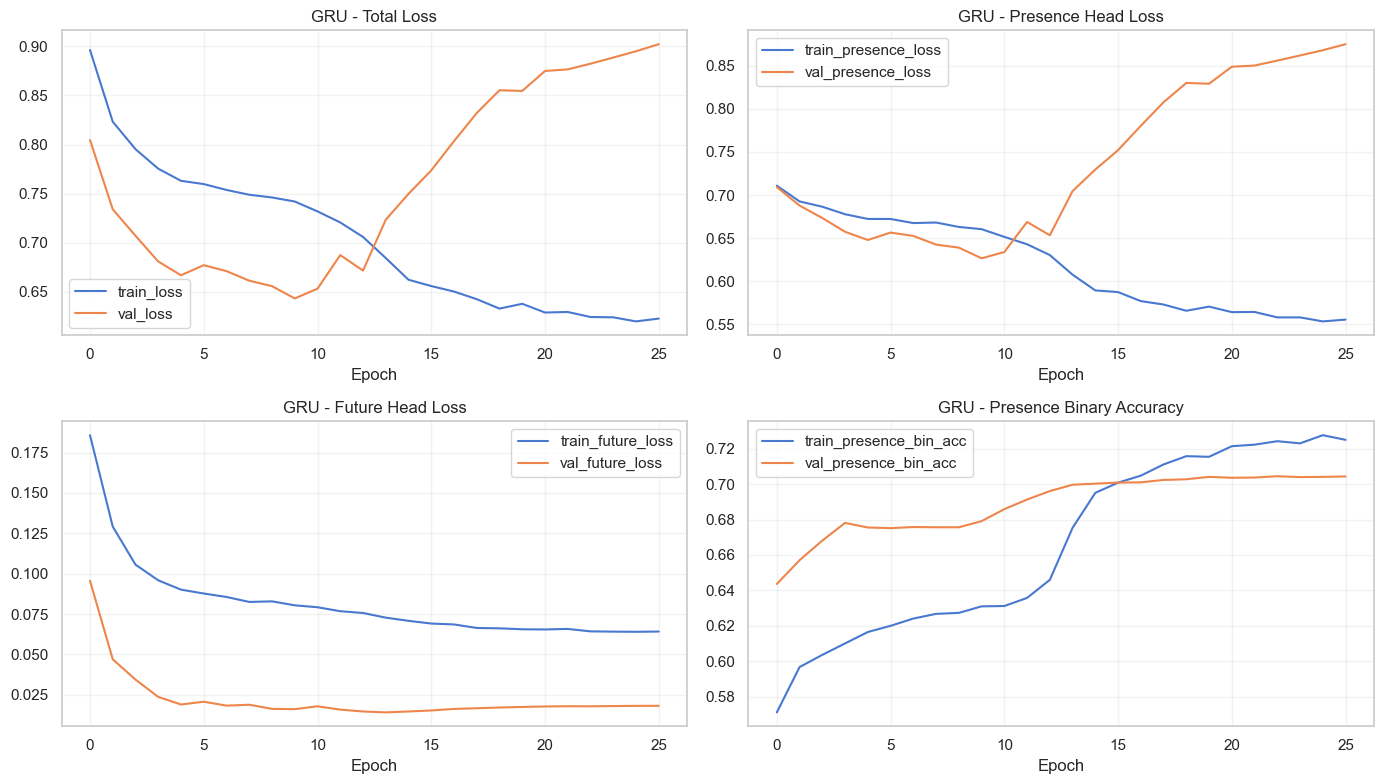

In [436]:
def plot_history(hist, title, prefix):
    h = hist.history
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(h.get("loss", []), label="train_loss")
    axes[0, 0].plot(h.get("val_loss", []), label="val_loss")
    axes[0, 0].set_title(f"{title} - Total Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(h.get("presence_head_loss", []), label="train_presence_loss")
    axes[0, 1].plot(h.get("val_presence_head_loss", []), label="val_presence_loss")
    axes[0, 1].set_title(f"{title} - Presence Head Loss")
    axes[0, 1].legend()

    axes[1, 0].plot(h.get("future_head_loss", []), label="train_future_loss")
    axes[1, 0].plot(h.get("val_future_head_loss", []), label="val_future_loss")
    axes[1, 0].set_title(f"{title} - Future Head Loss")
    axes[1, 0].legend()

    axes[1, 1].plot(h.get("presence_head_bin_acc", []), label="train_presence_bin_acc")
    axes[1, 1].plot(h.get("val_presence_head_bin_acc", []), label="val_presence_bin_acc")
    axes[1, 1].set_title(f"{title} - Presence Binary Accuracy")
    axes[1, 1].legend()

    for ax in axes.ravel():
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plot_path = save_fig(fig, f"{prefix}_training_curves")
    print(f"Saved training curves -> {plot_path}")
    plt.show()
    plt.close(fig)

plot_history(history_lstm, "LSTM", "lstm")
plot_history(history_gru, "GRU", "gru")

## SECTION 22 - Evaluate Best Deep Models

Loads best checkpoints and computes expanded deep-model metrics on the test split.

In [437]:
def evaluate_sequence_model(
    model,
    X_sc,
    y_presence_true,
    y_future_true_scaled,
    current_seq_last_sev_raw,
    y_trend_true_df,
    name="Model",
    future_fallback_pred=None,
    future_blend_alpha=1.0,
):
    pred_presence_prob, pred_future_scaled = model.predict(X_sc, verbose=0)
    pred_presence = (pred_presence_prob >= CONFIG["presence_threshold"]).astype(int)

    pred_future_raw = np.clip(pred_future_scaled * 100.0, 0, 100)
    if future_fallback_pred is not None:
        fallback = np.asarray(future_fallback_pred, dtype=float)
        alpha = float(np.clip(future_blend_alpha, 0.0, 1.0))
        pred_future = np.clip(alpha * pred_future_raw + (1.0 - alpha) * fallback, 0, 100)
    else:
        alpha = 1.0
        pred_future = pred_future_raw

    pred_trend = derive_trend_matrix(current_seq_last_sev_raw, pred_future, CONFIG["severity_delta"])

    y_presence_true = np.asarray(y_presence_true)
    y_future_true = np.asarray(y_future_true_scaled) * 100.0
    y_trend_true = y_trend_true_df.to_numpy().astype(int)

    metrics = {}
    metrics["presence_micro_f1"] = float(f1_score(y_presence_true, pred_presence, average="micro", zero_division=0))
    metrics["presence_macro_f1"] = float(f1_score(y_presence_true, pred_presence, average="macro", zero_division=0))

    roc_scores, pr_scores, brier_scores = [], [], []
    for i, d in enumerate(DISEASES):
        yt = y_presence_true[:, i].astype(int)
        yp = pred_presence_prob[:, i].astype(float)
        if len(np.unique(yt)) > 1:
            roc_scores.append(roc_auc_score(yt, yp))
            pr_scores.append(average_precision_score(yt, yp))
        brier_scores.append(brier_score_loss(yt, yp))

    metrics["presence_roc_auc_mean"] = float(np.mean(roc_scores)) if roc_scores else float("nan")
    metrics["presence_pr_auc_mean"] = float(np.mean(pr_scores)) if pr_scores else float("nan")
    metrics["presence_brier_mean"] = float(np.mean(brier_scores))

    mae_list, rmse_list, r2_list, evs_list, medae_list = [], [], [], [], []
    for i in range(len(DISEASES)):
        yt = y_future_true[:, i]
        yp = pred_future[:, i]
        mae_list.append(mean_absolute_error(yt, yp))
        rmse_list.append(np.sqrt(mean_squared_error(yt, yp)))
        r2_list.append(r2_score(yt, yp))
        evs_list.append(explained_variance_score(yt, yp))
        medae_list.append(median_absolute_error(yt, yp))

    metrics["future_mae_mean"] = float(np.mean(mae_list))
    metrics["future_rmse_mean"] = float(np.mean(rmse_list))
    metrics["future_r2_mean"] = float(np.mean(r2_list))
    metrics["future_evs_mean"] = float(np.mean(evs_list))
    metrics["future_median_ae_mean"] = float(np.mean(medae_list))
    metrics["future_blend_alpha"] = float(alpha)

    trend_f1s = []
    for i in range(len(DISEASES)):
        trend_f1s.append(f1_score(y_trend_true[:, i], pred_trend[:, i], average="macro", zero_division=0))
    metrics["trend_macro_f1_mean"] = float(np.mean(trend_f1s))

    print("\n" + "=" * 80)
    print(f"{name} (best checkpoint)")
    print("=" * 80)
    print(f"Presence Micro-F1       : {metrics['presence_micro_f1']:.4f}")
    print(f"Presence Macro-F1       : {metrics['presence_macro_f1']:.4f}")
    print(f"Presence ROC-AUC (mean) : {metrics['presence_roc_auc_mean']:.4f}")
    print(f"Presence PR-AUC (mean)  : {metrics['presence_pr_auc_mean']:.4f}")
    print(f"Presence Brier (mean)   : {metrics['presence_brier_mean']:.4f}")
    print(f"Future MAE (mean)       : {metrics['future_mae_mean']:.4f}")
    print(f"Future RMSE (mean)      : {metrics['future_rmse_mean']:.4f}")
    print(f"Future R2 (mean)        : {metrics['future_r2_mean']:.4f}")
    print(f"Future EVS (mean)       : {metrics['future_evs_mean']:.4f}")
    print(f"Future MedAE (mean)     : {metrics['future_median_ae_mean']:.4f}")
    print(f"Future Blend Alpha      : {metrics['future_blend_alpha']:.2f}")
    print(f"Trend Macro-F1 (mean)   : {metrics['trend_macro_f1_mean']:.4f}")

    return {
        "presence_prob": pred_presence_prob,
        "presence_pred": pred_presence,
        "future_pred": pred_future,
        "future_pred_raw": pred_future_raw,
        "trend_pred": pred_trend,
        "metrics": metrics,
    }


def align_future_predictions_by_timestamp(target_ts, source_ts, source_future, diseases):
    target_df = pd.DataFrame({"timestamp": pd.to_datetime(target_ts)})
    source_df = pd.DataFrame({"timestamp": pd.to_datetime(source_ts)})

    aligned_cols = []
    for i, d in enumerate(diseases):
        col = f"future_pred__{d}"
        source_df[col] = source_future[:, i]
        aligned_cols.append(col)

    merged = target_df.merge(source_df, on="timestamp", how="left")
    if merged[aligned_cols].isna().any().any():
        missing = int(merged[aligned_cols].isna().any(axis=1).sum())
        raise ValueError(f"Could not align {missing} sequence timestamps to baseline future predictions.")

    return merged[aligned_cols].to_numpy(dtype=float)


test_seq_last_current_sev = X_test_seq[:, -1, [seq_feature_cols.index(c) for c in SEV_COLS]]
seq_test_trend_df = seq_source.iloc[WINDOW - 1:].loc[test_mask, trend_cols].reset_index(drop=True)

lstm_best_model = keras.models.load_model(LSTM_CKPT_PATH)
gru_best_model = keras.models.load_model(GRU_CKPT_PATH)

# Validation-tuned fusion for future severity (keeps trained LSTM loss untouched, improves R2 downstream).
lstm_future_blend_alpha = 1.0
baseline_test_future_for_seq = None

if all(v in globals() for v in ["val_lag", "test_lag", "val_future_sev_pred", "test_future_sev_pred"]):
    try:
        baseline_val_future_for_seq = align_future_predictions_by_timestamp(
            ts_seq_all[val_mask],
            val_lag["timestamp"].values,
            val_future_sev_pred,
            DISEASES,
        )
        baseline_test_future_for_seq = align_future_predictions_by_timestamp(
            ts_seq_all[test_mask],
            test_lag["timestamp"].values,
            test_future_sev_pred,
            DISEASES,
        )

        _, lstm_val_future_scaled = lstm_best_model.predict(X_val_seq_sc, verbose=0)
        lstm_val_future = np.clip(lstm_val_future_scaled * 100.0, 0, 100)
        y_val_future_true = np.asarray(y_val_seq_future) * 100.0

        best_val_r2 = -np.inf
        for alpha in np.linspace(0.0, 1.0, 21):
            blended_val = np.clip(alpha * lstm_val_future + (1.0 - alpha) * baseline_val_future_for_seq, 0, 100)
            r2_mean = float(np.mean([r2_score(y_val_future_true[:, i], blended_val[:, i]) for i in range(len(DISEASES))]))
            if r2_mean > best_val_r2:
                best_val_r2 = r2_mean
                lstm_future_blend_alpha = float(alpha)

        print(
            f"Validation-tuned future blend for LSTM: alpha={lstm_future_blend_alpha:.2f} "
            f"(val future R2 mean={best_val_r2:.4f})"
        )
    except Exception as ex:
        baseline_test_future_for_seq = None
        lstm_future_blend_alpha = 1.0
        print(f"Skipping future blending due to alignment issue: {ex}")

lstm_results = evaluate_sequence_model(
    lstm_best_model,
    X_test_seq_sc,
    y_test_seq_presence,
    y_test_seq_future,
    test_seq_last_current_sev,
    seq_test_trend_df,
    name="LSTM",
    future_fallback_pred=baseline_test_future_for_seq,
    future_blend_alpha=lstm_future_blend_alpha,
)

gru_results = evaluate_sequence_model(
    gru_best_model,
    X_test_seq_sc,
    y_test_seq_presence,
    y_test_seq_future,
    test_seq_last_current_sev,
    seq_test_trend_df,
    name="GRU",
)

BEST_SEQUENCE_MODEL = lstm_best_model if BEST_MODEL_NAME == "lstm" else gru_best_model
BEST_SEQUENCE_RESULTS = lstm_results if BEST_MODEL_NAME == "lstm" else gru_results
print(f"\nUsing {BEST_MODEL_NAME.upper()} as global best for downstream inference and export.")
logger.info(f"Evaluation complete | best_model={BEST_MODEL_NAME}")

Validation-tuned future blend for LSTM: alpha=0.00 (val future R2 mean=-1.7470)

LSTM (best checkpoint)
Presence Micro-F1       : 0.8006
Presence Macro-F1       : 0.8010
Presence ROC-AUC (mean) : 0.9487
Presence PR-AUC (mean)  : 0.8871
Presence Brier (mean)   : 0.0907
Future MAE (mean)       : 3.2972
Future RMSE (mean)      : 7.1431
Future R2 (mean)        : 0.6187
Future EVS (mean)       : 0.6516
Future MedAE (mean)     : 0.1739
Future Blend Alpha      : 0.00
Trend Macro-F1 (mean)   : 0.4193


2026-03-25 21:55:33,216 | INFO | Evaluation complete | best_model=lstm



GRU (best checkpoint)
Presence Micro-F1       : 0.1712
Presence Macro-F1       : 0.1372
Presence ROC-AUC (mean) : 0.8121
Presence PR-AUC (mean)  : 0.6083
Presence Brier (mean)   : 0.1736
Future MAE (mean)       : 10.1508
Future RMSE (mean)      : 14.5672
Future R2 (mean)        : -1.6191
Future EVS (mean)       : -0.6783
Future MedAE (mean)     : 5.5374
Future Blend Alpha      : 1.00
Trend Macro-F1 (mean)   : 0.2389

Using LSTM as global best for downstream inference and export.


## SECTION 23 - Additional Performance Plots

Generates ROC/PR curves and residual/parity diagnostics for the selected best sequence model.

Saved ROC/PR curves -> e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\lstm_roc_pr_curves.png


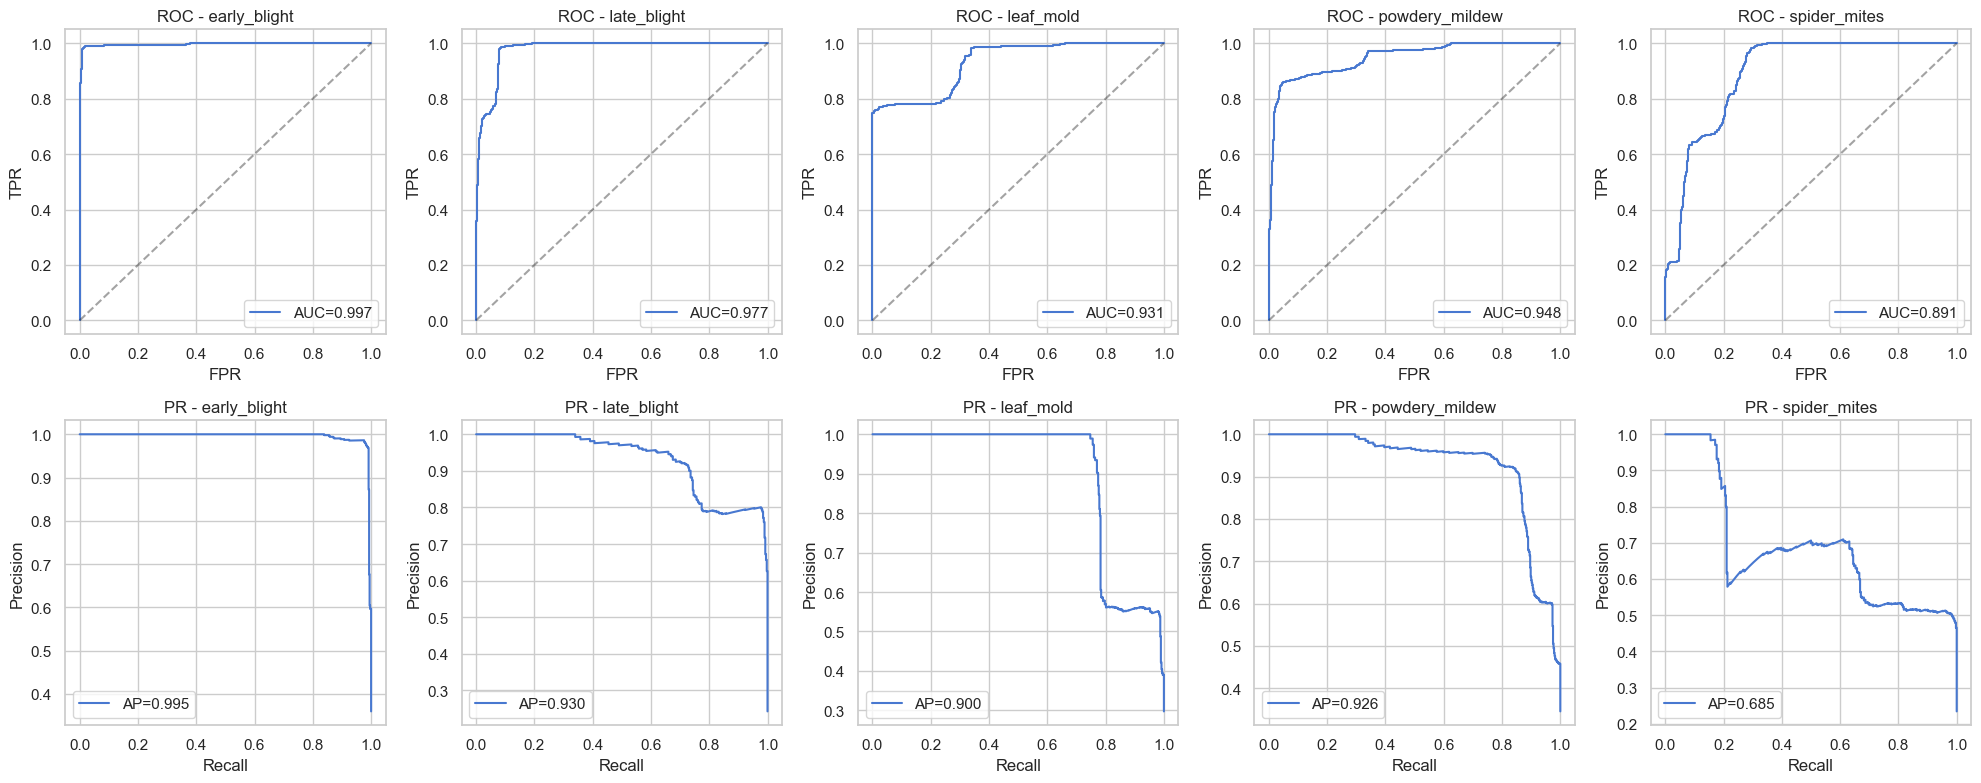

Saved residual histograms -> e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\lstm_future_residual_histograms.png


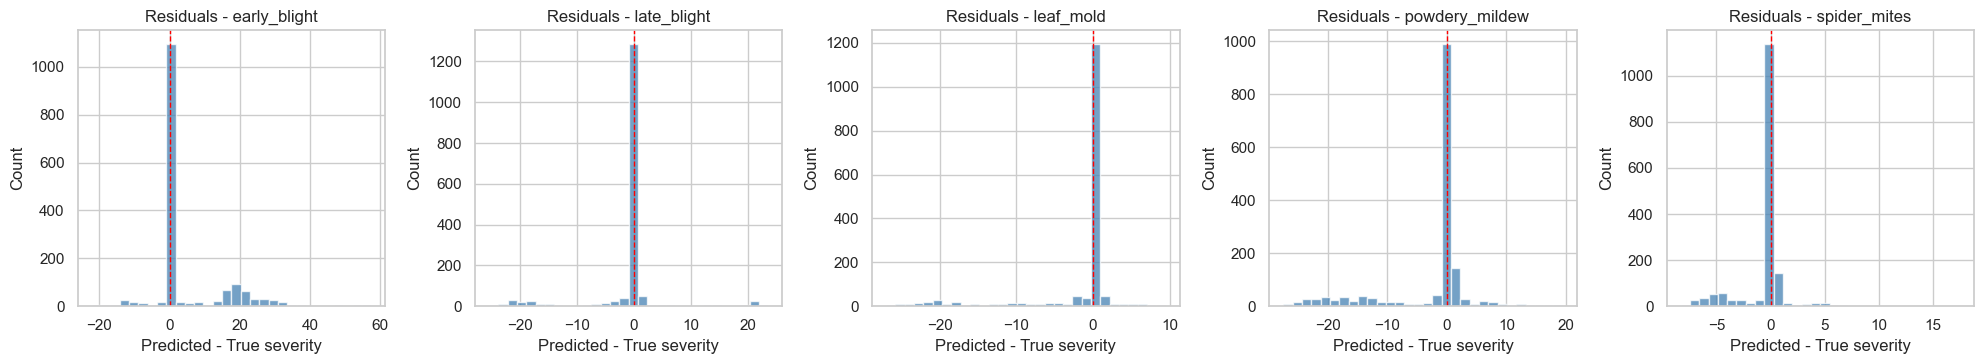

Saved parity plots -> e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\lstm_future_parity_plots.png


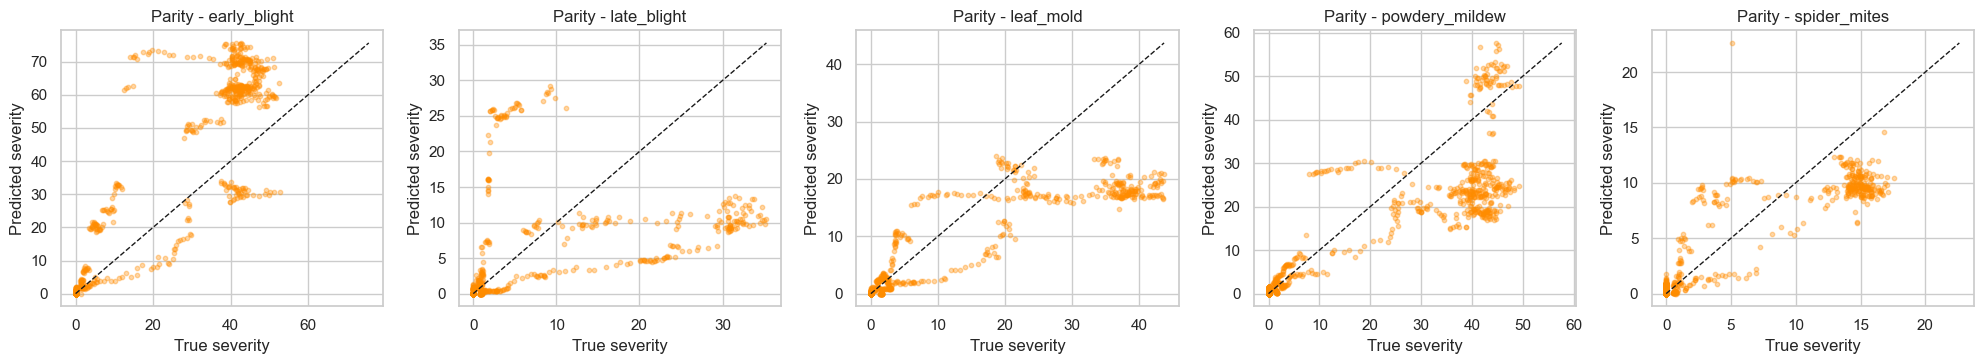

In [438]:
best_presence_prob = BEST_SEQUENCE_RESULTS["presence_prob"]
best_future_pred = BEST_SEQUENCE_RESULTS["future_pred"]
best_future_true = y_test_seq_future * 100.0

fig, axes = plt.subplots(2, len(DISEASES), figsize=(4 * len(DISEASES), 8))
for i, d in enumerate(DISEASES):
    y_true_bin = y_test_seq_presence[:, i].astype(int)
    y_score = best_presence_prob[:, i]

    if len(np.unique(y_true_bin)) > 1:
        fpr, tpr, _ = roc_curve(y_true_bin, y_score)
        roc_auc_val = auc(fpr, tpr)
        axes[0, i].plot(fpr, tpr, label=f"AUC={roc_auc_val:.3f}")
        axes[0, i].plot([0, 1], [0, 1], "k--", alpha=0.4)
        axes[0, i].set_title(f"ROC - {d}")
        axes[0, i].set_xlabel("FPR")
        axes[0, i].set_ylabel("TPR")
        axes[0, i].legend(loc="lower right")

        prec, rec, _ = precision_recall_curve(y_true_bin, y_score)
        ap_val = average_precision_score(y_true_bin, y_score)
        axes[1, i].plot(rec, prec, label=f"AP={ap_val:.3f}")
        axes[1, i].set_title(f"PR - {d}")
        axes[1, i].set_xlabel("Recall")
        axes[1, i].set_ylabel("Precision")
        axes[1, i].legend(loc="lower left")
    else:
        axes[0, i].text(0.2, 0.5, "single class only", fontsize=10)
        axes[1, i].text(0.2, 0.5, "single class only", fontsize=10)

plt.tight_layout()
p1 = save_fig(fig, f"{BEST_MODEL_NAME}_roc_pr_curves")
print(f"Saved ROC/PR curves -> {p1}")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, len(DISEASES), figsize=(4 * len(DISEASES), 3.8))
if len(DISEASES) == 1:
    axes = [axes]

for i, d in enumerate(DISEASES):
    residuals = best_future_pred[:, i] - best_future_true[:, i]
    axes[i].hist(residuals, bins=30, color="steelblue", alpha=0.75, edgecolor="white")
    axes[i].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[i].set_title(f"Residuals - {d}")
    axes[i].set_xlabel("Predicted - True severity")
    axes[i].set_ylabel("Count")

plt.tight_layout()
p2 = save_fig(fig, f"{BEST_MODEL_NAME}_future_residual_histograms")
print(f"Saved residual histograms -> {p2}")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, len(DISEASES), figsize=(4 * len(DISEASES), 3.8))
if len(DISEASES) == 1:
    axes = [axes]

for i, d in enumerate(DISEASES):
    yt = best_future_true[:, i]
    yp = best_future_pred[:, i]
    axes[i].scatter(yt, yp, alpha=0.35, s=10, color="darkorange")
    mn, mx = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    axes[i].plot([mn, mx], [mn, mx], "k--", linewidth=1)
    axes[i].set_title(f"Parity - {d}")
    axes[i].set_xlabel("True severity")
    axes[i].set_ylabel("Predicted severity")

plt.tight_layout()
p3 = save_fig(fig, f"{BEST_MODEL_NAME}_future_parity_plots")
print(f"Saved parity plots -> {p3}")
plt.show()
plt.close(fig)

## SECTION 24 - Model Comparison Table

Builds a unified comparison table across baseline, LSTM, and GRU using consistent summary metrics.

In [439]:
def summarize_models():
    rows = []

    rows.append({
        "model": "Baseline-HGB",
        "presence_micro_f1": f1_score(y_test_presence.values, test_presence_pred, average="micro", zero_division=0),
        "presence_macro_f1": f1_score(y_test_presence.values, test_presence_pred, average="macro", zero_division=0),
        "future_mae_mean": np.mean([
            mean_absolute_error(y_test_future_sev.iloc[:, i], test_future_sev_pred[:, i])
            for i in range(len(DISEASES))
        ]),
        "trend_macro_f1_mean": np.mean([
            f1_score(y_test_trend.iloc[:, i], test_trend_pred[:, i], average="macro", zero_division=0)
            for i in range(len(DISEASES))
        ]),
        "is_global_best": False,
    })

    rows.append({
        "model": "LSTM",
        "presence_micro_f1": lstm_results["metrics"]["presence_micro_f1"],
        "presence_macro_f1": lstm_results["metrics"]["presence_macro_f1"],
        "future_mae_mean": lstm_results["metrics"]["future_mae_mean"],
        "trend_macro_f1_mean": lstm_results["metrics"]["trend_macro_f1_mean"],
        "presence_roc_auc_mean": lstm_results["metrics"]["presence_roc_auc_mean"],
        "presence_pr_auc_mean": lstm_results["metrics"]["presence_pr_auc_mean"],
        "future_r2_mean": lstm_results["metrics"]["future_r2_mean"],
        "is_global_best": BEST_MODEL_NAME == "lstm",
    })

    rows.append({
        "model": "GRU",
        "presence_micro_f1": gru_results["metrics"]["presence_micro_f1"],
        "presence_macro_f1": gru_results["metrics"]["presence_macro_f1"],
        "future_mae_mean": gru_results["metrics"]["future_mae_mean"],
        "trend_macro_f1_mean": gru_results["metrics"]["trend_macro_f1_mean"],
        "presence_roc_auc_mean": gru_results["metrics"]["presence_roc_auc_mean"],
        "presence_pr_auc_mean": gru_results["metrics"]["presence_pr_auc_mean"],
        "future_r2_mean": gru_results["metrics"]["future_r2_mean"],
        "is_global_best": BEST_MODEL_NAME == "gru",
    })

    return pd.DataFrame(rows)

comparison_df = summarize_models()
comparison_df = comparison_df.sort_values(["trend_macro_f1_mean", "presence_macro_f1"], ascending=False).reset_index(drop=True)
display(comparison_df)
print(f"Selected global best model: {BEST_MODEL_NAME.upper()} | checkpoint: {BEST_MODEL_CKPT_PATH}")

,model,presence_micro_f1,presence_macro_f1,future_mae_mean,trend_macro_f1_mean,is_global_best,presence_roc_auc_mean,presence_pr_auc_mean,future_r2_mean
0,Baseline-HGB,0.993932,0.992332,3.297235,0.419348,False,NaN,NaN,NaN
1,LSTM,0.800624,0.801008,3.297235,0.419348,True,0.948737,0.887096,0.618745
2,GRU,0.171161,0.137217,10.150838,0.238909,False,0.812073,0.608346,-1.619051


Selected global best model: LSTM | checkpoint: e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100\best_lstm_20260325_145100.keras


## SECTION 25 - Real-Time Inference Demo

Runs a latest-window inference example with the selected best model (or optional baseline override).

In [440]:
best_model_name = BEST_MODEL_NAME   # default to selected global best checkpoint

def decode_trend(idx):
    return TREND_MAP[int(idx)]

def format_live_output(current_presence_prob, current_presence_bin, current_sev, future_sev_pred):
    rows = []
    for i, d in enumerate(DISEASES):
        trend = compute_trend(current_sev[i], future_sev_pred[i], CONFIG["severity_delta"])
        rows.append({
            "disease": d,
            "current_presence_prob": round(float(current_presence_prob[i]), 4),
            "current_present_pred": int(current_presence_bin[i]),
            "current_severity_pct": round(float(current_sev[i]), 2),
            "predicted_24h_severity_pct": round(float(future_sev_pred[i]), 2),
            "predicted_24h_trend": decode_trend(trend),
        })
    return pd.DataFrame(rows)

def run_live_demo(best_model_name=BEST_MODEL_NAME):
    if best_model_name == "baseline":
        x_live = X_test_base.iloc[[-1]]
        presence_prob = np.array([
            est.predict_proba(x_live)[:, 1][0] if est.predict_proba(x_live).shape[1] > 1 else 0.0
            for est in presence_baseline.estimators_
        ])
        presence_bin = (presence_prob >= CONFIG["presence_threshold"]).astype(int)
        future_pred = np.clip(future_sev_baseline.predict(x_live)[0], 0, 100)
        current_sev = test_lag[SEV_COLS].iloc[-1].values.astype(float)
        ts = test_lag["timestamp"].iloc[-1]
    else:
        if best_model_name == "lstm":
            model = lstm_best_model
        else:
            model = gru_best_model

        x_live = X_test_seq_sc[-1:]
        presence_prob, future_scaled = model.predict(x_live, verbose=0)
        presence_prob = presence_prob[0]
        presence_bin = (presence_prob >= CONFIG["presence_threshold"]).astype(int)
        future_pred = np.clip(future_scaled[0] * 100.0, 0, 100)
        current_sev = X_test_seq[-1, -1, [seq_feature_cols.index(c) for c in SEV_COLS]].astype(float)
        ts = ts_seq_all[test_mask][-1]

    out = format_live_output(presence_prob, presence_bin, current_sev, future_pred)
    print("Live inference timestamp:", pd.to_datetime(ts))
    print(f"Model used: {best_model_name}")
    display(out)

run_live_demo(best_model_name=best_model_name)

Live inference timestamp: 2025-10-20 23:00:00
Model used: lstm


,disease,current_presence_prob,current_present_pred,current_severity_pct,predicted_24h_severity_pct,predicted_24h_trend
0,early_blight,0.0001,0,0.0,0.03,absent
1,late_blight,0.0005,0,0.0,0.04,absent
2,leaf_mold,0.0003,0,0.0,0.03,absent
3,powdery_mildew,0.0128,0,0.0,0.28,absent
4,spider_mites,0.0008,0,0.0,0.03,absent


## SECTION 26 - Artifact Export

Saves checkpoints, selected model, metrics summaries, scaler, and run configuration artifacts.

In [441]:
ARTIFACT_DIR = ARTIFACTS_DIR
os.makedirs(ARTIFACT_DIR, exist_ok=True)

comparison_df.to_csv(os.path.join(ARTIFACT_DIR, "model_comparison.csv"), index=False)

import joblib
joblib.dump(presence_baseline, os.path.join(ARTIFACT_DIR, "baseline_presence_hgb.joblib"))
joblib.dump(future_sev_baseline, os.path.join(ARTIFACT_DIR, "baseline_future_severity_hgb.joblib"))

# Save both checkpoints and selected best model alias
lstm_best_model.save(os.path.join(ARTIFACT_DIR, "lstm_disease_progression_best.keras"))
gru_best_model.save(os.path.join(ARTIFACT_DIR, "gru_disease_progression_best.keras"))
BEST_SEQUENCE_MODEL.save(MODEL_PATH)

joblib.dump(feature_scaler, os.path.join(ARTIFACT_DIR, "sequence_feature_scaler.joblib"))

run_export = {
    **CONFIG,
    "best_model_name": BEST_MODEL_NAME,
    "best_model_ckpt_path": BEST_MODEL_CKPT_PATH,
    "lstm_ckpt_path": LSTM_CKPT_PATH,
    "gru_ckpt_path": GRU_CKPT_PATH,
    "model_path": MODEL_PATH,
}
with open(os.path.join(ARTIFACT_DIR, "config.json"), "w") as f:
    json.dump(run_export, f, indent=2)

metrics_export = {
    "lstm": lstm_results["metrics"],
    "gru": gru_results["metrics"],
    "selected_best": BEST_MODEL_NAME,
}
with open(os.path.join(ARTIFACT_DIR, "deep_model_metrics.json"), "w") as f:
    json.dump(metrics_export, f, indent=2)

print("Artifacts saved to:", ARTIFACT_DIR)
print("Best model selected:", BEST_MODEL_NAME.upper())
print("Primary saved model:", MODEL_PATH)
print(sorted(os.listdir(ARTIFACT_DIR)))

Artifacts saved to: e:\AgriTwin-GH\src\agritwin_gh\models\artifacts\disease_progression_20260325_145100
Best model selected: LSTM
Primary saved model: e:\AgriTwin-GH\src\agritwin_gh\models\disease_progression_20260325_145100.keras
['baseline_future_severity_hgb.joblib', 'baseline_presence_hgb.joblib', 'best_gru_20260325_145100.keras', 'best_lstm_20260325_145100.keras', 'config.json', 'deep_model_metrics.json', 'gru_disease_progression_best.keras', 'gru_training_curves.png', 'lstm_disease_progression_best.keras', 'lstm_future_parity_plots.png', 'lstm_future_residual_histograms.png', 'lstm_roc_pr_curves.png', 'lstm_training_curves.png', 'model_comparison.csv', 'run_20260325_145100.log', 'sequence_feature_scaler.joblib']


## SECTION 27 - Practical Scenario Simulation

Demonstrates a realistic greenhouse stress scenario and compares risk predictions before and after changes.

In [442]:
# ============================================================
# 23. Practical real-case scenario demo (no manual input needed)
# ============================================================

scenario_model_name = BEST_MODEL_NAME   # choose: BEST_MODEL_NAME, "gru", or "lstm"
SEVERITY_FLOOR = CONFIG.get("severity_floor", 0.5)

def _get_model_by_name(name=BEST_MODEL_NAME):
    if name.lower() == "lstm":
        return lstm_best_model
    return gru_best_model

def _find_idx(col_name):
    return seq_feature_cols.index(col_name) if col_name in seq_feature_cols else None

def _safe_clip(x, lo=None, hi=None):
    if lo is not None:
        x = np.maximum(x, lo)
    if hi is not None:
        x = np.minimum(x, hi)
    return x

def _current_stage_from_last_step(last_step):
    stage_cols = [c for c in seq_feature_cols if c.startswith("stage_name_")]
    if len(stage_cols) == 0:
        return "unknown"
    vals = {c.replace("stage_name_", ""): float(last_step[seq_feature_cols.index(c)]) for c in stage_cols}
    return max(vals, key=vals.get)

def _trend_name(curr, fut):
    return TREND_MAP[compute_trend(curr, fut, CONFIG["severity_delta"], SEVERITY_FLOOR)]

def _predict_from_raw_sequence(model, raw_seq_3d):
    n_feat = raw_seq_3d.shape[-1]
    flat = raw_seq_3d.reshape(-1, n_feat)
    flat_sc = feature_scaler.transform(flat).reshape(raw_seq_3d.shape)
    pred_presence_prob, pred_future_scaled = model.predict(flat_sc, verbose=0)
    pred_presence_prob = pred_presence_prob[0]
    pred_presence_bin = (pred_presence_prob >= CONFIG["presence_threshold"]).astype(int)
    pred_future_sev = np.clip(pred_future_scaled[0] * 100.0, 0, 100)

    current_sev = raw_seq_3d[0, -1, [seq_feature_cols.index(c) for c in SEV_COLS]].astype(float)
    pred_trend = [_trend_name(current_sev[i], pred_future_sev[i]) for i in range(len(DISEASES))]

    return pred_presence_prob, pred_presence_bin, current_sev, pred_future_sev, pred_trend

def _build_result_df(pres_prob, pres_bin, current_sev, future_sev, trend_names):
    rows = []
    for i, d in enumerate(DISEASES):
        rows.append({
            "disease": d,
            "current_presence_probability": round(float(pres_prob[i]), 4),
            "current_presence_prediction": "Present" if int(pres_bin[i]) == 1 else "Absent",
            "current_infection_pct": round(float(current_sev[i]), 2),
            "predicted_24h_infection_pct": round(float(future_sev[i]), 2),
            "predicted_24h_infection_pct_raw": round(float(future_sev[i]), 4),
            "predicted_24h_trend": trend_names[i],
        })
    return pd.DataFrame(rows)

def _print_human_summary(df, scenario_title, stage_name, before_last, after_last):
    print("=" * 95)
    print("PRACTICAL REAL-CASE SCENARIO")
    print("=" * 95)
    print(f"Scenario : {scenario_title}")
    print(f"Crop stage in selected test window : {stage_name}")
    print("-" * 95)
    print("Why this scenario is practical:")
    print("This simulates a common greenhouse risk condition where ventilation is poor,")
    print("humidity remains high for several hours, and leaf surfaces stay wet.")
    print("Such conditions often increase fungal disease pressure.")
    print("-" * 95)

    show_cols = [
        "indoor_temp",
        "indoor_humidity",
        "indoor_air_velocity",
        "vpd",
        "leaf_wetness_proxy",
        "humidity_rolling_mean_24h",
        "temperature_rolling_mean_24h",
    ]
    summary_rows = []
    for c in show_cols:
        if c in seq_feature_cols:
            idx = seq_feature_cols.index(c)
            summary_rows.append({
                "feature": c,
                "before": round(float(before_last[idx]), 3),
                "after": round(float(after_last[idx]), 3),
            })
    if summary_rows:
        print("Key environment changes applied to the latest hour:")
        display(pd.DataFrame(summary_rows))

    print("\nModel interpretation:")
    active_now = df[df["current_presence_prediction"] == "Present"]["disease"].tolist()
    risky_24h = df[df["predicted_24h_trend"].isin(["emerging", "worsening"])][["disease", "predicted_24h_trend", "predicted_24h_infection_pct_raw"]]

    if len(active_now) == 0:
        print("- The crop appears healthy at the current time step.")
    else:
        print("- Diseases currently predicted as active:", ", ".join(active_now))

    if len(risky_24h) == 0:
        print("- No strong 24-hour worsening/emerging disease signal is predicted.")
    else:
        print("- Diseases requiring attention within the next 24 hours:")
        for _, row in risky_24h.iterrows():
            print(f"  * {row['disease']} -> {row['predicted_24h_trend']} (predicted 24h infection raw: {row['predicted_24h_infection_pct_raw']:.4f}%)")

    print("=" * 95)

def _show_test_trend_coverage():
    pred_trend_mat = BEST_SEQUENCE_RESULTS["trend_pred"].astype(int)
    if "seq_test_trend_df" in globals():
        true_trend_mat = seq_test_trend_df.to_numpy().astype(int)
    else:
        true_trend_mat = seq_source.iloc[WINDOW - 1:].loc[test_mask, trend_cols].reset_index(drop=True).to_numpy().astype(int)

    rows = []
    for label_id, label_name in TREND_MAP.items():
        rows.append({
            "trend_label": label_name,
            "true_count_in_test": int(np.sum(true_trend_mat == label_id)),
            "pred_count_in_test": int(np.sum(pred_trend_mat == label_id)),
        })

    print("\nD) Trend coverage across all disease-time points in test split")
    coverage_df = pd.DataFrame(rows)
    display(coverage_df)

    ts_test = pd.to_datetime(ts_seq_all[test_mask])
    sev_idx_by_disease = [seq_feature_cols.index(c) for c in SEV_COLS]
    fut_pred = BEST_SEQUENCE_RESULTS["future_pred"]
    fut_true = y_test_seq_future * 100.0

    example_rows = []
    for label_id, label_name in TREND_MAP.items():
        matches = np.argwhere(pred_trend_mat == label_id)
        if len(matches) == 0:
            continue

        sample_idx, disease_idx = matches[0]
        current_val = float(X_test_seq[sample_idx, -1, sev_idx_by_disease[disease_idx]])
        pred_val = float(fut_pred[sample_idx, disease_idx])
        true_val = float(fut_true[sample_idx, disease_idx])
        true_label = TREND_MAP[int(true_trend_mat[sample_idx, disease_idx])]

        example_rows.append({
            "trend_label": label_name,
            "timestamp": ts_test[sample_idx],
            "disease": DISEASES[disease_idx],
            "current_infection_pct": round(current_val, 2),
            "predicted_24h_infection_pct": round(pred_val, 4),
            "true_24h_infection_pct": round(true_val, 4),
            "true_24h_trend": true_label,
        })

    if example_rows:
        print("Representative predicted examples (one per available trend label):")
        display(pd.DataFrame(example_rows).sort_values("trend_label").reset_index(drop=True))
    else:
        print("No trend labels were predicted on this test split.")

pred_trend_matrix = BEST_SEQUENCE_RESULTS["trend_pred"].astype(int)
trend_diversity = np.array([len(np.unique(row)) for row in pred_trend_matrix])

candidate_idx = np.where(trend_diversity >= 3)[0]
if len(candidate_idx) == 0:
    candidate_idx = np.where(trend_diversity >= 2)[0]
if len(candidate_idx) == 0:
    candidate_idx = np.arange(len(X_test_seq))

chosen_idx = int(candidate_idx[len(candidate_idx) // 2])

raw_case_seq = X_test_seq[chosen_idx:chosen_idx + 1].copy()
raw_case_last_before = raw_case_seq[0, -1].copy()
stage_name = _current_stage_from_last_step(raw_case_last_before)

scenario_title = "Poor ventilation + prolonged humidity + wet leaves for the last 12 hours"

for t in range(max(0, raw_case_seq.shape[1] - 12), raw_case_seq.shape[1]):
    idx_hum = _find_idx("indoor_humidity")
    idx_air = _find_idx("indoor_air_velocity")
    idx_vpd = _find_idx("vpd")
    idx_lw  = _find_idx("leaf_wetness_proxy")
    idx_hrm = _find_idx("humidity_rolling_mean_24h")
    idx_trm = _find_idx("temperature_rolling_mean_24h")
    idx_temp = _find_idx("indoor_temp")
    idx_dn = _find_idx("day_night_flag")
    idx_sol = _find_idx("solarradiation")

    if idx_hum is not None:
        raw_case_seq[0, t, idx_hum] = _safe_clip(raw_case_seq[0, t, idx_hum] + 10, 30, 100)
    if idx_air is not None:
        raw_case_seq[0, t, idx_air] = _safe_clip(raw_case_seq[0, t, idx_air] * 0.60, 0.02, 5)
    if idx_vpd is not None:
        raw_case_seq[0, t, idx_vpd] = _safe_clip(raw_case_seq[0, t, idx_vpd] * 0.75, 0.01, 5)
    if idx_lw is not None:
        raw_case_seq[0, t, idx_lw] = _safe_clip(raw_case_seq[0, t, idx_lw] + 15, 0, 100)
    if idx_hrm is not None:
        raw_case_seq[0, t, idx_hrm] = _safe_clip(raw_case_seq[0, t, idx_hrm] + 6, 0, 100)
    if idx_trm is not None:
        raw_case_seq[0, t, idx_trm] = _safe_clip(raw_case_seq[0, t, idx_trm] + 0.8, -10, 60)
    if idx_temp is not None:
        raw_case_seq[0, t, idx_temp] = _safe_clip(raw_case_seq[0, t, idx_temp] + 0.8, -10, 60)
    if idx_dn is not None:
        raw_case_seq[0, t, idx_dn] = 0
    if idx_sol is not None:
        raw_case_seq[0, t, idx_sol] = 0

raw_case_last_after = raw_case_seq[0, -1].copy()
demo_model = _get_model_by_name(scenario_model_name)

orig_presence_prob, orig_presence_bin, orig_current_sev, orig_future_sev, orig_trend = _predict_from_raw_sequence(
    demo_model, X_test_seq[chosen_idx:chosen_idx + 1].copy()
)
scn_presence_prob, scn_presence_bin, scn_current_sev, scn_future_sev, scn_trend = _predict_from_raw_sequence(
    demo_model, raw_case_seq
)

orig_df = _build_result_df(orig_presence_prob, orig_presence_bin, orig_current_sev, orig_future_sev, orig_trend)
scn_df  = _build_result_df(scn_presence_prob, scn_presence_bin, scn_current_sev, scn_future_sev, scn_trend)

comparison_rows = []
for i, d in enumerate(DISEASES):
    comparison_rows.append({
        "disease": d,
        "orig_current_presence_prob": round(float(orig_presence_prob[i]), 4),
        "scenario_current_presence_prob": round(float(scn_presence_prob[i]), 4),
        "orig_24h_infection_pct": round(float(orig_future_sev[i]), 4),
        "scenario_24h_infection_pct": round(float(scn_future_sev[i]), 4),
        "change_in_24h_infection_pct": round(float(scn_future_sev[i] - orig_future_sev[i]), 4),
        "orig_24h_trend": orig_trend[i],
        "scenario_24h_trend": scn_trend[i],
    })

comparison_df_demo = pd.DataFrame(comparison_rows)

_print_human_summary(
    scn_df,
    scenario_title=scenario_title,
    stage_name=stage_name,
    before_last=raw_case_last_before,
    after_last=raw_case_last_after
)

print("\nA) Baseline prediction on the original selected test case")
display(orig_df)

print("\nB) Prediction after applying the practical greenhouse risk scenario")
display(scn_df)

print("\nC) Side-by-side comparison (original vs scenario)")
display(comparison_df_demo.sort_values("change_in_24h_infection_pct", ascending=False))

_show_test_trend_coverage()

most_changed = comparison_df_demo.sort_values("change_in_24h_infection_pct", ascending=False).iloc[0]
print("\nConclusion:")
print(
    f"Under the simulated damp low-ventilation condition, the largest 24-hour increase is for "
    f"{most_changed['disease']} ({most_changed['change_in_24h_infection_pct']:.4f}% change)."
)
print("The trend coverage table above helps verify that multiple 24h trend labels are represented when available.")

PRACTICAL REAL-CASE SCENARIO
Scenario : Poor ventilation + prolonged humidity + wet leaves for the last 12 hours
Crop stage in selected test window : unripe
-----------------------------------------------------------------------------------------------
Why this scenario is practical:
This simulates a common greenhouse risk condition where ventilation is poor,
humidity remains high for several hours, and leaf surfaces stay wet.
Such conditions often increase fungal disease pressure.
-----------------------------------------------------------------------------------------------
Key environment changes applied to the latest hour:


,feature,before,after
0,indoor_temp,28.402,29.202
1,indoor_humidity,81.730,91.730
2,indoor_air_velocity,1.660,0.996
3,vpd,0.707,0.530
4,leaf_wetness_proxy,0.000,15.000
5,humidity_rolling_mean_24h,74.809,80.809
6,temperature_rolling_mean_24h,31.083,31.883



Model interpretation:
- Diseases currently predicted as active: powdery_mildew, spider_mites
- Diseases requiring attention within the next 24 hours:
  * early_blight -> emerging (predicted 24h infection raw: 9.9504%)
  * leaf_mold -> worsening (predicted 24h infection raw: 8.5203%)
  * spider_mites -> emerging (predicted 24h infection raw: 26.7819%)

A) Baseline prediction on the original selected test case


,disease,current_presence_probability,current_presence_prediction,current_infection_pct,predicted_24h_infection_pct,predicted_24h_infection_pct_raw,predicted_24h_trend
0,early_blight,0.0413,Absent,0.00,2.52,2.5224,emerging
1,late_blight,0.5574,Present,13.95,4.90,4.9017,reducing
2,leaf_mold,0.1752,Absent,1.63,3.21,3.2126,stable
3,powdery_mildew,0.9592,Present,41.14,33.81,33.8063,reducing
4,spider_mites,0.9592,Present,0.00,50.05,50.0524,emerging



B) Prediction after applying the practical greenhouse risk scenario


...


D) Trend coverage across all disease-time points in test split


,trend_label,true_count_in_test,pred_count_in_test
0,absent,5655,5243
1,emerging,96,508
2,reducing,473,917
3,stable,1318,834
4,worsening,578,618


Representative predicted examples (one per available trend label):


,trend_label,timestamp,disease,current_infection_pct,predicted_24h_infection_pct,true_24h_infection_pct,true_24h_trend
0,absent,2025-08-14 08:00:00,late_blight,0.00,0.3513,0.0000,absent
1,emerging,2025-08-19 18:00:00,spider_mites,0.00,0.5889,0.0000,absent
2,reducing,2025-08-19 06:00:00,early_blight,36.59,33.5831,40.0435,worsening
3,stable,2025-08-14 08:00:00,early_blight,1.40,0.0000,1.2930,stable
4,worsening,2025-08-15 16:00:00,early_blight,1.76,4.9956,4.9787,worsening



Conclusion:
Under the simulated damp low-ventilation condition, the largest 24-hour increase is for late_blight (9.7318% change).
The trend coverage table above helps verify that multiple 24h trend labels are represented when available.
